# Module 02 — Repeat-Pass Change Detection

**Files used:**
- `NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5` (reference, 2026-07-10)
- `NISAR_L1_PR_RSLC_026_034_D_073_4005_DHDH_A_20260722T133916_20260722T133951_P05023_N_F_J_001.h5` (secondary, 2026-07-22)

**Product / band:** RSLC (L1), L-band, both track 034 / frame 073, both descending — a genuine repeat-pass pair, 12 days apart (confirmed in Module 01 / `docs/data_inventory.md` from each file's own `identification` metadata, not filename parsing).

**Why these files:** same track/frame family lets us compare backscatter at (approximately) the same imaging geometry across two dates — the basic building block of repeat-pass SAR change detection.

**Region:** same as Module 01 — northwestern India, agricultural plains rising into Himalayan foothill terrain (~74.8–78.2°E, ~29.4–32.1°N, from `boundingPolygon`).

## Scope & Caveats

This notebook demonstrates a **backscatter-differencing change-detection technique** using two real repeat-pass acquisitions. It is **not** a validated flood, urban, or vegetation-change event — no ground truth or independent event record has been checked against this scene/date pair. The technique shown here is generically applicable to those use cases, but the specific difference map below should be read only as "backscatter changed here between 2026-07-10 and 2026-07-22", not as a confirmed real-world event.

A real, non-trivial complication is used honestly rather than hidden: File 1 was acquired in mixed mode (half range bandwidth) while File 2 was acquired at full bandwidth, so the two products have different range pixel spacing. Handling that is most of this notebook's substance.

Geographic language throughout is strictly technical (terrain/elevation/backscatter).

## Theory recap

See **Module 00, Section 8** for the full explanation. In short: comparing backscatter across two repeat-pass acquisitions requires (1) **geometric coregistration** -- matching pixels to the same ground location, which this notebook does using each product's own range/azimuth metadata -- and (2) **radiometric consistency** between acquisitions, which this notebook does *not* attempt. Theory predicts that over truly unchanged ground, a properly calibrated difference map should average close to 0 dB; we check that prediction below and use the result to help explain what we're actually seeing.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

In [2]:
REF_PATH = SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5"
SEC_PATH = SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_026_034_D_073_4005_DHDH_A_20260722T133916_20260722T133951_P05023_N_F_J_001.h5"

ref = open_product(REF_PATH)
sec = open_product(SEC_PATH)

for label, prod in [("Reference (File 1)", ref), ("Secondary (File 2)", sec)]:
    print(f"{label}:")
    print(f"  track/frame:       {prod.track_number} / {prod.frame_number}   orbit: {prod.orbit_pass_direction}")
    print(f"  acquisition (UTC): {prod.zero_doppler_start_time} -> {prod.zero_doppler_end_time}")
    print(f"  isMixedMode:       {prod.identification.get('isMixedMode')}")
    print(f"  freqA range spacing: {prod.range_spacing('A'):.4f} m   azimuth spacing: {prod.azimuth_spacing():.7f} s")
    print()

assert ref.track_number == sec.track_number and ref.frame_number == sec.frame_number, "not the same track/frame!"
print("Confirmed: same track/frame family, same descending pass geometry.")

Reference (File 1):
  track/frame:       34 / 73   orbit: Descending
  acquisition (UTC): 2026-07-10T13:39:17.000000000 -> 2026-07-10T13:39:52.999342105
  isMixedMode:       True
  freqA range spacing: 6.2457 m   azimuth spacing: 0.0006579 s

Secondary (File 2):
  track/frame:       34 / 73   orbit: Descending
  acquisition (UTC): 2026-07-22T13:39:16.000000000 -> 2026-07-22T13:39:51.999342105
  isMixedMode:       False
  freqA range spacing: 3.1228 m   azimuth spacing: 0.0006579 s

Confirmed: same track/frame family, same descending pass geometry.


## The real co-registration problem here

File 1's Frequency A range spacing (~6.25 m) is exactly ~2x coarser than File 2's (~3.12 m) — File 1 was processed in mixed mode at half the range bandwidth, File 2 at full bandwidth. Their slant-range start values also differ by ~1.9 km, and their azimuth (zero-Doppler) start times differ by ~1 second. Naively subtracting the two arrays would compare unrelated pixels.

`nisar_tools.preprocess.coregister_offsets` computes, from each product's own `slantRange`/`zeroDopplerTime` axes alone (no cross-correlation): (1) the integer range-multilook factor needed to bring the secondary's range sampling down to match the reference's, and (2) the integer pixel offsets between their starting samples. This is a coarse, metadata-driven alignment — adequate for a multilooked backscatter-differencing demo, but **not** a substitute for the sub-pixel, cross-correlation-refined coregistration real InSAR/change-detection pipelines require (see the closing cell).

In [3]:
offsets = prep.coregister_offsets(
    ref_range_start=ref.slant_range("A")[0],
    ref_range_spacing=ref.range_spacing("A"),
    ref_azimuth_start=ref.zero_doppler_time()[0],
    ref_azimuth_spacing=ref.azimuth_spacing(),
    sec_range_start=sec.slant_range("A")[0],
    sec_range_spacing=sec.range_spacing("A"),
    sec_azimuth_start=sec.zero_doppler_time()[0],
    sec_azimuth_spacing=sec.azimuth_spacing(),
)
print("Computed geometric alignment (reference-grid units):", offsets)

Computed geometric alignment (reference-grid units): {'range_ml_factor': 2, 'row_offset_lines': -1520, 'col_offset_samples': -308}


In [4]:
ref_dset = ref.get_slc_dataset("A", "HH")
win_rows, win_cols = 2048, 2048
ref_row_slice, ref_col_slice = prep.center_window(ref_dset.shape[0], ref_dset.shape[1], win_rows, win_cols)

range_ml = offsets["range_ml_factor"]
row_off = offsets["row_offset_lines"]
col_off = offsets["col_offset_samples"]

# Secondary window: same reference-grid location, translated by the computed offsets
# and widened in range by range_ml (since the secondary has range_ml x as many range
# samples per unit ground distance).
sec_row_slice = slice(ref_row_slice.start + row_off, ref_row_slice.stop + row_off)
sec_col_slice = slice(ref_col_slice.start * range_ml + col_off, ref_col_slice.stop * range_ml + col_off)

print("Reference window (rows, cols):", ref_row_slice, ref_col_slice)
print("Secondary window (rows, cols), pre-multilook:", sec_row_slice, sec_col_slice)

ref_win = ref.read_slc_block("A", "HH", ref_row_slice, ref_col_slice)
sec_win_raw = sec.read_slc_block("A", "HH", sec_row_slice, sec_col_slice)
print("Reference window shape:", ref_win.shape, "  Secondary raw window shape:", sec_win_raw.shape)

Reference window (rows, cols): slice(26336, 28384, None) slice(12328, 14376, None)
Secondary window (rows, cols), pre-multilook: slice(24816, 26864, None) slice(24348, 28444, None)


Reference window shape: (2048, 2048)   Secondary raw window shape: (2048, 4096)


In [5]:
az_looks = 4  # extra azimuth-only multilook for speckle reduction, applied equally to both

ref_power_ml = prep.multilook(prep.power(ref_win), az_looks, 1)
sec_power_ml = prep.multilook(prep.power(sec_win_raw), az_looks, range_ml)

print("Reference multilooked shape:", ref_power_ml.shape)
print("Secondary multilooked shape:", sec_power_ml.shape)
assert ref_power_ml.shape == sec_power_ml.shape, "coregistration/multilook shape mismatch"
print("Shapes match: reference and secondary are now on a common grid.")

Reference multilooked shape: (512, 2048)
Secondary multilooked shape: (512, 2048)
Shapes match: reference and secondary are now on a common grid.


## Backscatter difference map

Theory check (Module 00, Section 8): over truly unchanged, correctly calibrated ground,
the mean backscatter difference should be close to 0 dB.
  Observed: mean = +1.54 dB, std = 8.02 dB
  The mean is 1.54 dB away from the 0 dB prediction -- worth explaining,
  not ignoring. The banding pattern in the map below is the likely explanation.


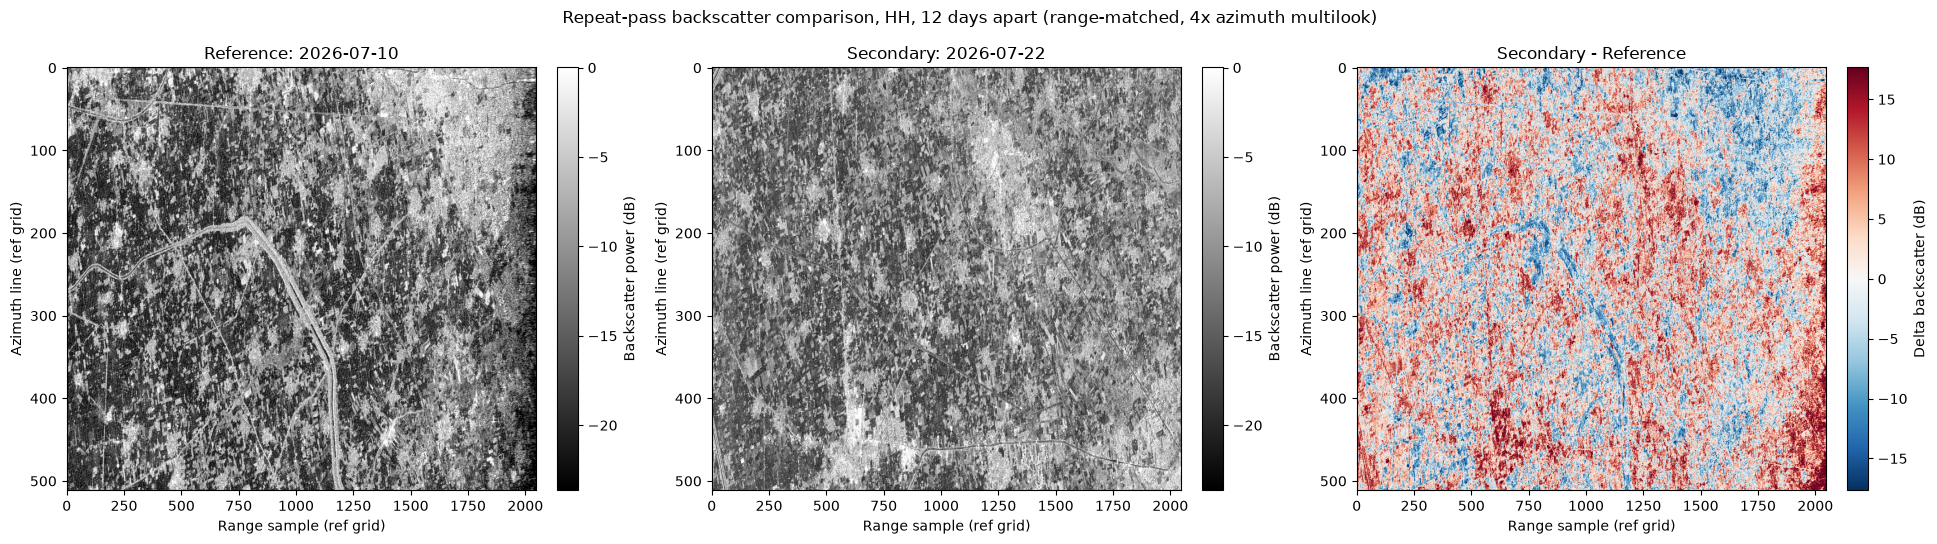

In [6]:
ref_db = prep.power_db(ref_power_ml)
sec_db = prep.power_db(sec_power_ml)
diff_db = sec_db - ref_db

diff_mean = float(np.nanmean(diff_db))
diff_std = float(np.nanstd(diff_db))
print("Theory check (Module 00, Section 8): over truly unchanged, correctly calibrated ground,")
print("the mean backscatter difference should be close to 0 dB.")
print(f"  Observed: mean = {diff_mean:+.2f} dB, std = {diff_std:.2f} dB")
if abs(diff_mean) < 0.5:
    print("  The mean is close to 0, consistent with no large-scale calibration bias here.")
else:
    print(f"  The mean is {abs(diff_mean):.2f} dB away from the 0 dB prediction -- worth explaining,")
    print("  not ignoring. The banding pattern in the map below is the likely explanation.")

shared_vmin = min(np.percentile(ref_db, 2), np.percentile(sec_db, 2))
shared_vmax = max(np.percentile(ref_db, 98), np.percentile(sec_db, 98))

fig, axes = viz.new_figure(ncols=3)
viz.imshow_amplitude(
    axes[0], ref_db, cmap="gray", vmin=shared_vmin, vmax=shared_vmax,
    colorbar_label="Backscatter power (dB)", title=f"Reference: {ref.zero_doppler_start_time[:10]}",
    xlabel="Range sample (ref grid)", ylabel="Azimuth line (ref grid)",
)
viz.imshow_amplitude(
    axes[1], sec_db, cmap="gray", vmin=shared_vmin, vmax=shared_vmax,
    colorbar_label="Backscatter power (dB)", title=f"Secondary: {sec.zero_doppler_start_time[:10]}",
    xlabel="Range sample (ref grid)", ylabel="Azimuth line (ref grid)",
)
viz.imshow_diverging(
    axes[2], diff_db, colorbar_label="Delta backscatter (dB)", title="Secondary - Reference",
    xlabel="Range sample (ref grid)", ylabel="Azimuth line (ref grid)",
)
fig.suptitle("Repeat-pass backscatter comparison, HH, 12 days apart (range-matched, 4x azimuth multilook)")
fig.tight_layout()
plt.show()

## Interpreting the difference map

In the diverging colormap above, red = backscatter *increased* from reference to secondary date, blue = backscatter *decreased*. This is the basic building block behind operational repeat-pass techniques: e.g. large, spatially coherent backscatter drops over previously land-like areas are a common flood-mapping signal; localized increases can indicate new construction; broad, field-scale changes can reflect crop growth stage or soil moisture.

**A caveat worth flagging rather than glossing over:** the difference map shows broad vertical banding (stripes several hundred samples wide) layered on top of finer, field-scale texture. Banding this wide is not consistent with fine-scale land-cover change, and is more likely a **range-dependent radiometric difference** between the two acquisitions — plausible here specifically because File 1 (mixed-mode, half bandwidth) and File 2 (full bandwidth) were processed differently, and elevation-antenna-pattern or gain calibration can vary smoothly across range. This notebook only geometrically coregisters the two acquisitions; it does **not** perform radiometric cross-calibration between them, so some of what's colored in the difference map is very likely calibration bias, not surface change. **None of the fine-scale interpretation is being claimed as a confirmed event either** — distinguishing genuine land-cover change from ordinary temporal/soil-moisture variability or residual speckle requires validated event dates and, ideally, a longer multi-date stack rather than a single two-date comparison.

Fraction of multilooked pixels with |change| > 3.0 dB: 72.1%
(As noted above, this fraction almost certainly overcounts real change: it includes the
 range-dependent banding, which is more likely a cross-acquisition calibration artifact.)


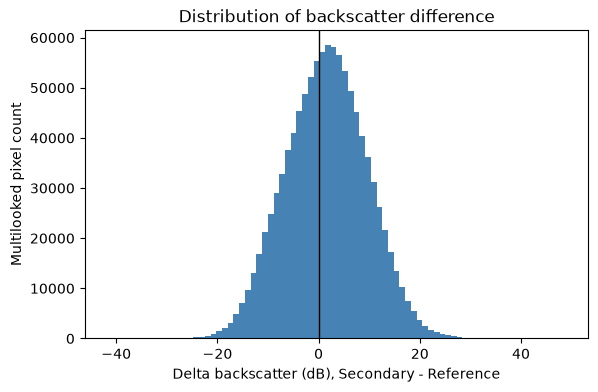

In [7]:
threshold_db = 3.0
frac_change = float(np.mean(np.abs(diff_db) > threshold_db))
print(f"Fraction of multilooked pixels with |change| > {threshold_db} dB: {frac_change:.1%}")
print("(As noted above, this fraction almost certainly overcounts real change: it includes the")
print(" range-dependent banding, which is more likely a cross-acquisition calibration artifact.)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(diff_db.ravel(), bins=80, color="steelblue")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Delta backscatter (dB), Secondary - Reference")
ax.set_ylabel("Multilooked pixel count")
ax.set_title("Distribution of backscatter difference")
plt.show()

In [8]:
ref.close()
sec.close()

## What real-world deployment would additionally require

- A validated event date/window (flood warning, damage report, planting calendar, etc.) to justify comparing these two specific dates in the first place.
- Radiometric cross-calibration between the two acquisitions (not just geometric coregistration) — the range-dependent banding seen above is a concrete example of why this matters, especially when comparing acquisitions processed differently (mixed-mode vs. full-bandwidth, as here).
- Sub-pixel, cross-correlation-refined coregistration rather than the coarse metadata-derived integer offsets used here — necessary for any pixel-level (not just multilooked-patch-level) comparison.
- A longer multi-date stack (more than two acquisitions) to separate a genuine step-change from ordinary temporal variability (soil moisture, phenology, incidence-angle effects).
- Ground truth or an independent reference dataset (field reports, optical imagery, gauge/station data) to confirm what any detected change corresponds to physically.